In [ ]:
!pip install torch torchvision scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 77.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from PIL import Image
from torchvision import transforms

In [ ]:
CKPT_DIR = '/content/drive/MyDrive/COS30082Project/checkpoints'
VERIF_DIR = '/content/drive/MyDrive/COS30082Project/realDATA/verification_data'
PAIRS_FILE = '/content/drive/MyDrive/COS30082Project/realDATA/verification_pairs_val.txt'

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [ ]:
embed_net = torch.load(
    os.path.join(CKPT_DIR, 'embed_net_full.pt'),
    map_location=device,
    weights_only=False  # ensure full model object is loaded
)
embed_net.eval()

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (

In [ ]:
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [ ]:
pairs = []
with open(PAIRS_FILE, 'r') as f:
    for line in f:
        img1, img2, lbl = line.strip().split()
        pairs.append((img1, img2, int(lbl)))
print(f"Loaded {len(pairs)} verification trials")

Loaded 8805 verification trials


In [ ]:
# Compute similarity scores and labels
scores = []
labels = []

In [ ]:
for img1, img2, lbl in pairs:
    # Load images as PIL
    # Ensure we use the basename to avoid nested 'verification_data/'
    path1 = os.path.join(VERIF_DIR, os.path.basename(img1))
    path2 = os.path.join(VERIF_DIR, os.path.basename(img2))
    im1 = Image.open(path1).convert('RGB')
    im2 = Image.open(path2).convert('RGB')
    # Apply transform and move to device
    t1 = val_transform(im1).unsqueeze(0).to(device)
    t2 = val_transform(im2).unsqueeze(0).to(device)
    # Compute embeddings
    with torch.no_grad():
        e1 = embed_net(t1).cpu().numpy().flatten()
        e2 = embed_net(t2).cpu().numpy().flatten()
    # Cosine similarity as score
    sim = np.dot(e1, e2) / (np.linalg.norm(e1) * np.linalg.norm(e2))
    scores.append(sim)
    labels.append(lbl)

In [ ]:
# AUC calculation
fpr, tpr, thresholds = roc_curve(labels, scores)
roc_auc = auc(fpr, tpr)
print(f"Verification AUC: {roc_auc:.4f}")

Verification AUC: 0.8285


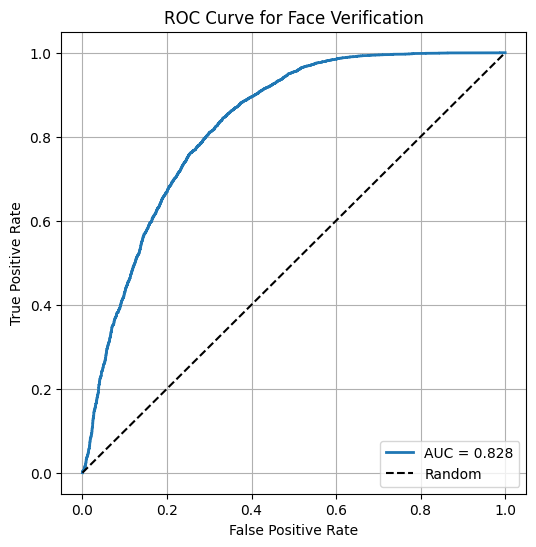

In [ ]:
# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}', linewidth=2)
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Face Verification')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
